In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from matplotlib.patches import Patch
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [26]:
# Cau hinh thu muc va ham luu bieu do
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    path = FIG_DIR / f'{name}.pdf'
    fig.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')


In [27]:
# Nap du lieu
DATA_PATHS = [
    Path('data/creditcard.csv'),
    Path('creditcard.csv'),
    Path('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv'),
]

data_path = next((path for path in DATA_PATHS if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Could not find creditcard.csv. Put it at data/creditcard.csv or creditcard.csv.'
    )

print(f'Loading data from: {data_path}')
df = pd.read_csv(data_path)
df.head()

Loading data from: data\creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
# Kiem tra tong quan du lieu
print(df.shape)
print(df.isnull().sum().sum(), 'missing values')
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

(284807, 31)
0 missing values
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## Biểu đồ EDA dùng cho báo cáo

Các biểu đồ dưới đây tập trung vào vấn đề chính của đề tài: dữ liệu mất cân bằng nặng, hành vi giao dịch theo số tiền/thời gian, và các biến có quan hệ mạnh với nhãn fraud. Mỗi biểu đồ được lưu dạng PDF trong thư mục `figures`.

Saved figure: figures\01_class_imbalance.pdf


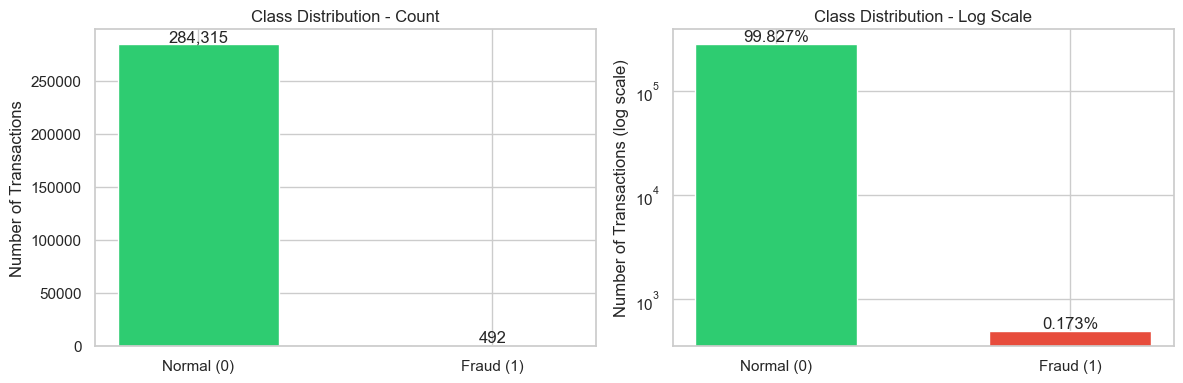

In [29]:
# Bieu do: muc do mat can bang nhan
counts = df['Class'].value_counts().sort_index()
labels = ['Normal (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=colors, width=0.55)
axes[0].set_title('Class Distribution - Count')
axes[0].set_ylabel('Number of Transactions')
for i, value in enumerate(counts.values):
    axes[0].text(i, value, f'{value:,}', ha='center', va='bottom')

axes[1].bar(labels, counts.values, color=colors, width=0.55)
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution - Log Scale')
axes[1].set_ylabel('Number of Transactions (log scale)')
for i, value in enumerate(counts.values):
    pct = value / counts.sum() * 100
    axes[1].text(i, value, f'{pct:.3f}%', ha='center', va='bottom')

plt.tight_layout()
save_fig(fig, '01_class_imbalance')
plt.show()


Saved figure: figures\02_amount_time_by_class.pdf


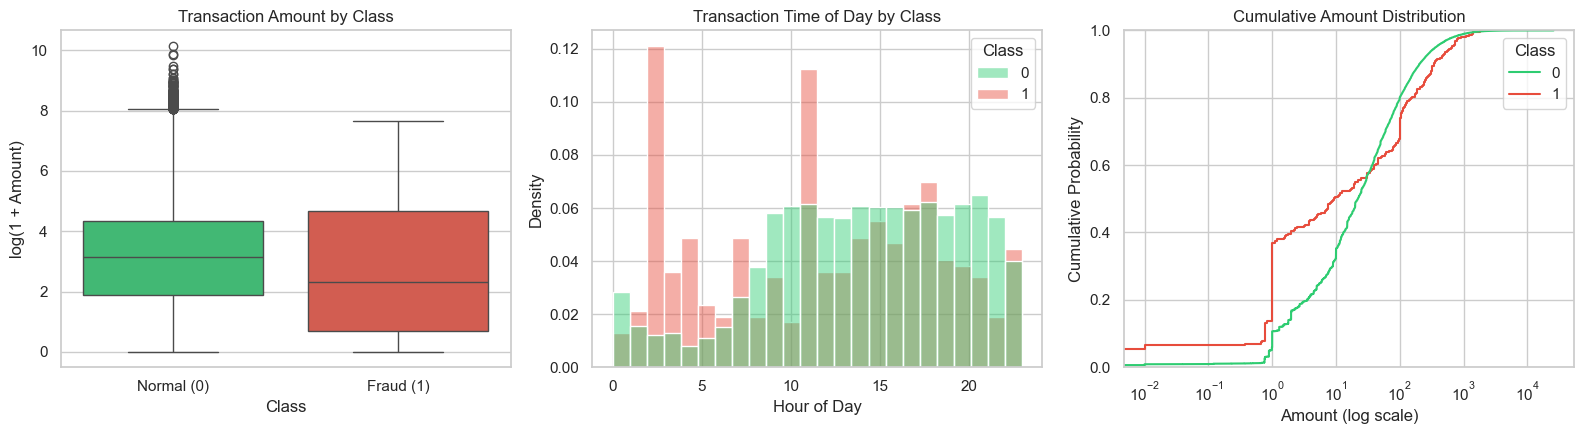

In [30]:
# Bieu do: Amount va Time theo tung nhan
df_report = df.copy()
df_report['Amount_log1p'] = np.log1p(df_report['Amount'])
df_report['Hour'] = (df_report['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=df_report, x='Class', y='Amount_log1p', ax=axes[0], palette=colors)
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('log(1 + Amount)')
axes[0].set_xticklabels(labels)

sns.histplot(data=df_report, x='Hour', hue='Class', bins=24, stat='density', common_norm=False,
             palette=colors, alpha=0.45, ax=axes[1])
axes[1].set_title('Transaction Time of Day by Class')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Density')

sns.ecdfplot(data=df_report, x='Amount', hue='Class', palette=colors, ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_title('Cumulative Amount Distribution')
axes[2].set_xlabel('Amount (log scale)')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
save_fig(fig, '02_amount_time_by_class')
plt.show()


Saved figure: figures\03_feature_correlation.pdf


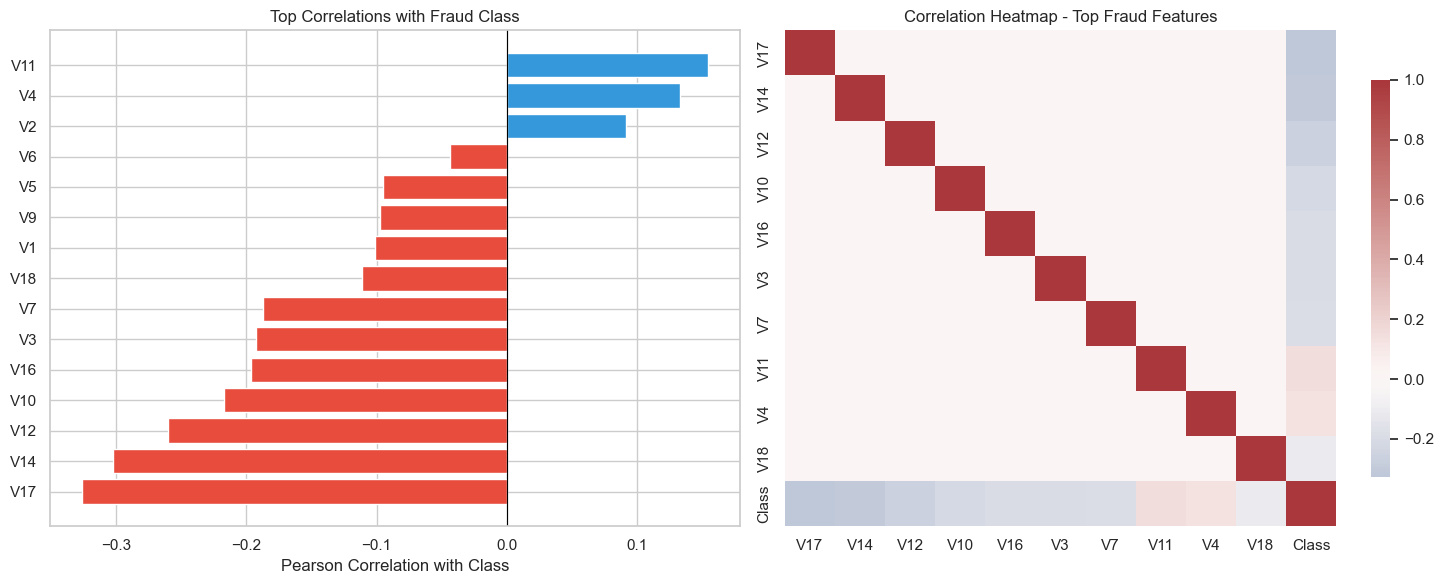

In [31]:
# Bieu do: cac bien lien quan manh voi nhan fraud
class_corr = (
    df.corr(numeric_only=True)['Class']
      .drop('Class')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)
top_corr = class_corr.head(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bar_colors = ['#e74c3c' if v < 0 else '#3498db' for v in top_corr.values]
axes[0].barh(top_corr.index, top_corr.values, color=bar_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top Correlations with Fraud Class')
axes[0].set_xlabel('Pearson Correlation with Class')

heatmap_cols = list(class_corr.head(10).index) + ['Class']
sns.heatmap(df[heatmap_cols].corr(), cmap='vlag', center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap - Top Fraud Features')

plt.tight_layout()
save_fig(fig, '03_feature_correlation')
plt.show()


Saved figure: figures\04_top_feature_distributions.pdf


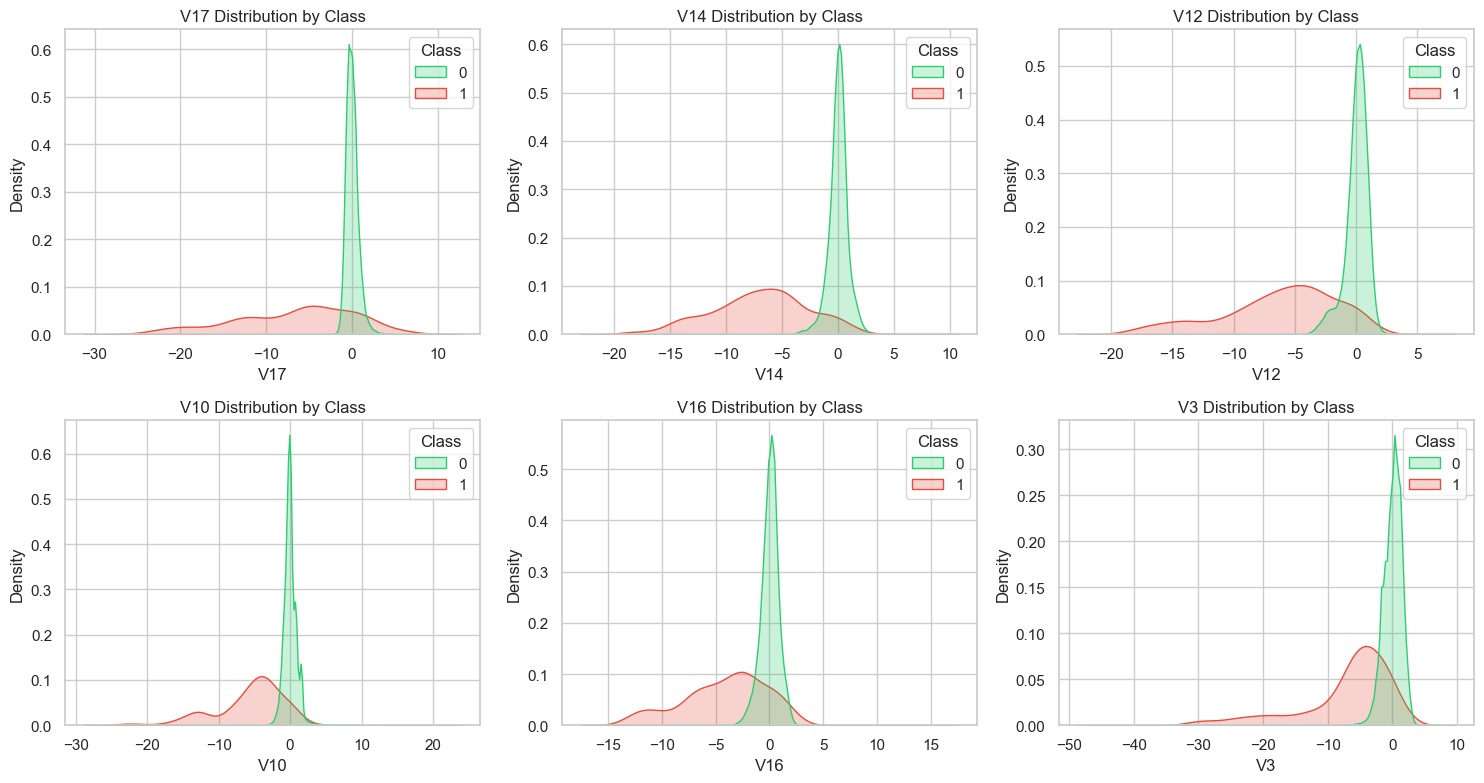

In [32]:
# Bieu do: phan phoi cac PCA feature noi bat
top_features = class_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    sns.kdeplot(data=df, x=feature, hue='Class', common_norm=False, fill=True,
                alpha=0.25, palette=colors, ax=ax)
    ax.set_title(f'{feature} Distribution by Class')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')

plt.tight_layout()
save_fig(fig, '04_top_feature_distributions')
plt.show()


Saved figure: figures\12_original_class_distribution.pdf


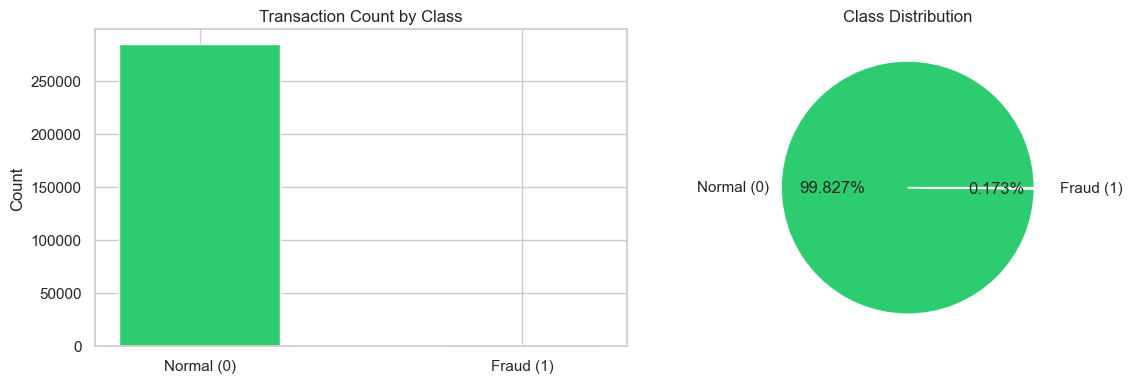

In [33]:
# Bieu do: phan phoi nhan co ban
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Normal (0)', 'Fraud (1)'],
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[1].set_title('Class Distribution')

plt.tight_layout()
save_fig(fig, '12_original_class_distribution')
plt.show()

Saved figure: figures\13_original_amount_time_distribution.pdf


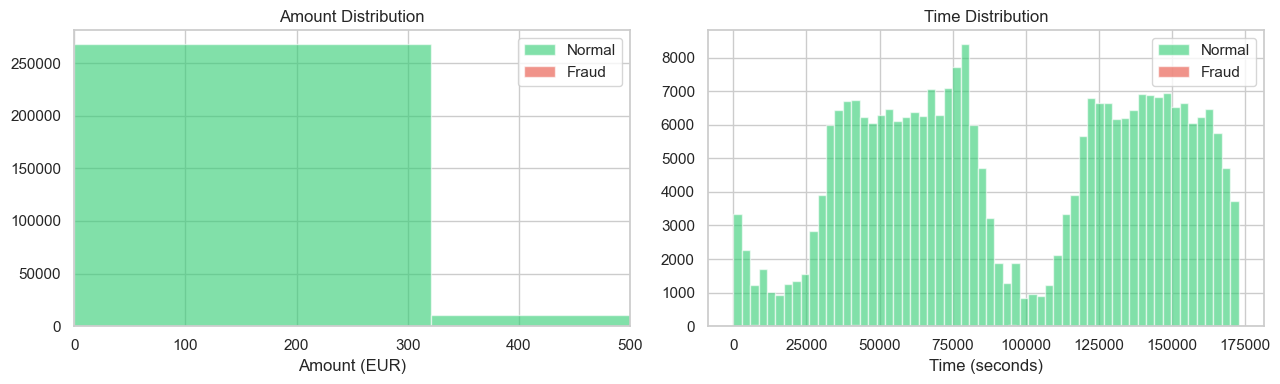

In [34]:
# Bieu do: phan phoi Amount va Time co ban
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    name = 'Normal' if label == 0 else 'Fraud'
    axes[0].hist(df[df['Class'] == label]['Amount'], bins=80, color=color, alpha=0.6, label=name)
    axes[1].hist(df[df['Class'] == label]['Time'],   bins=60, color=color, alpha=0.6, label=name)

axes[0].set_xlim(0, 500)
axes[0].set_title('Amount Distribution')
axes[0].set_xlabel('Amount (EUR)')
axes[0].legend()

axes[1].set_title('Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '13_original_amount_time_distribution')
plt.show()

In [35]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [36]:
# Tien xu ly du lieu
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuan hoa Amount va Time; cac cot V1-V28 da duoc PCA san
# Chi fit scaler tren train de tranh data leakage
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]  = scaler.transform(X_test[['Amount', 'Time']])

Saved figure: figures\08_train_test_class_distribution.pdf


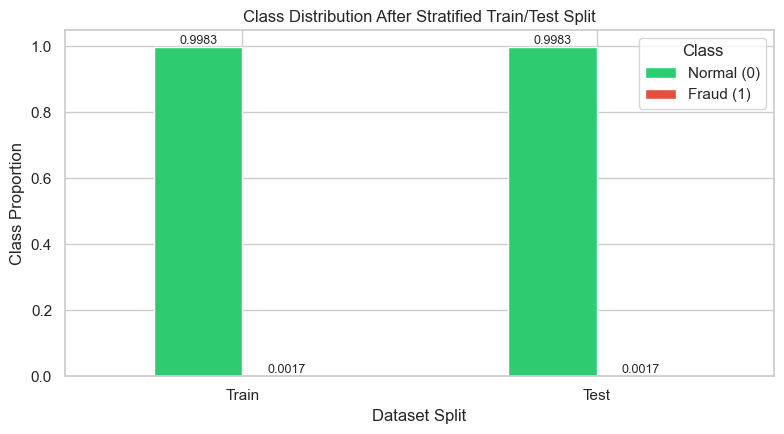

,Train,Test
Class,,
Normal (0),0.998271,0.99828
Fraud (1),0.001729,0.00172


In [37]:
# Bieu do: kiem tra ti le nhan sau khi chia train/test
split_counts = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True).sort_index(),
    'Test': y_test.value_counts(normalize=True).sort_index(),
}).rename(index={0: 'Normal (0)', 1: 'Fraud (1)'})

fig, ax = plt.subplots(figsize=(8, 4.5))
split_counts.T.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution After Stratified Train/Test Split')
ax.set_ylabel('Class Proportion')
ax.set_xlabel('Dataset Split')
ax.legend(title='Class')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9)

plt.tight_layout()
save_fig(fig, '08_train_test_class_distribution')
plt.show()

split_counts.round(6)


## Mô hình baseline

Logistic Regression được dùng làm baseline tuyến tính. Baseline này giúp báo cáo có mốc so sánh rõ ràng trước khi dùng các mô hình mạnh hơn như Random Forest và XGBoost.

In [38]:
# Mo hinh baseline: Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba_lr):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba_lr):.4f}')


              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC : 0.9722
PR-AUC  : 0.7159


In [39]:
# Mo hinh chinh: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # Can bang trong so cho lop fraud
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [40]:
# Danh gia Random Forest
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba):.4f}')

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.80      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9786
PR-AUC  : 0.8425


Saved figure: figures\14_random_forest_confusion_matrix.pdf


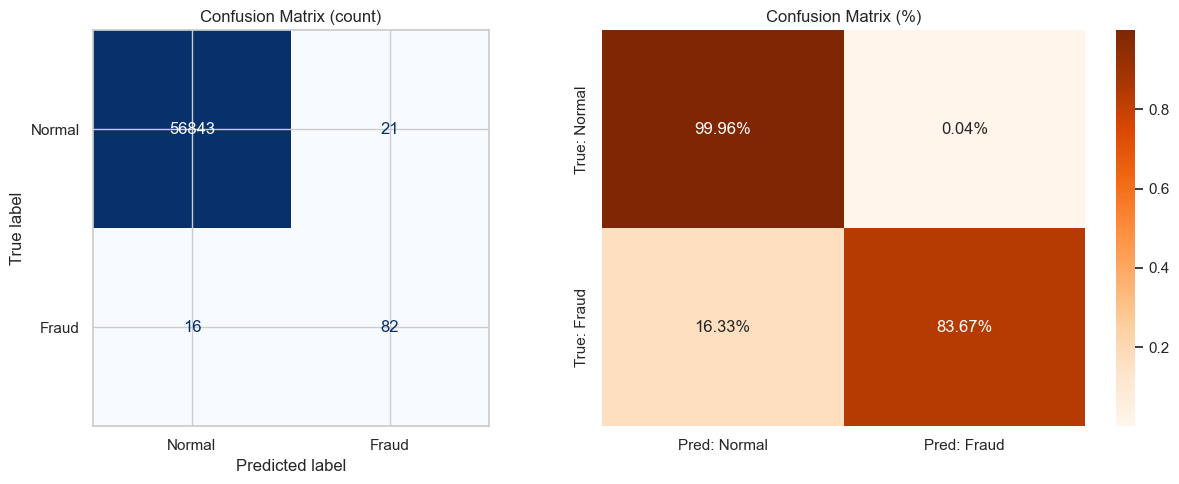

TN=56843  FP=21  FN=16  TP=82


In [41]:
# Bieu do: confusion matrix cua Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (count)')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: Normal', 'Pred: Fraud'],
            yticklabels=['True: Normal', 'True: Fraud'])
axes[1].set_title('Confusion Matrix (%)')

plt.tight_layout()
save_fig(fig, '14_random_forest_confusion_matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

Saved figure: figures\15_random_forest_roc_pr_curves.pdf


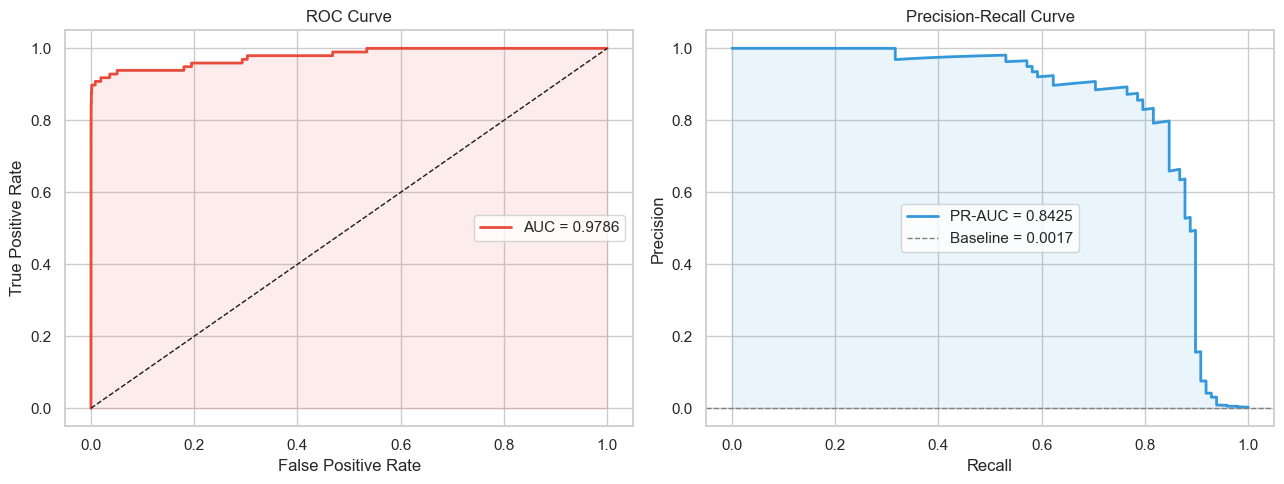

In [42]:
# Bieu do: ROC va Precision-Recall cua Random Forest
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#3498db', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.4f}')
axes[1].fill_between(rec, prec, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '15_random_forest_roc_pr_curves')
plt.show()

Saved figure: figures\16_random_forest_feature_importance.pdf


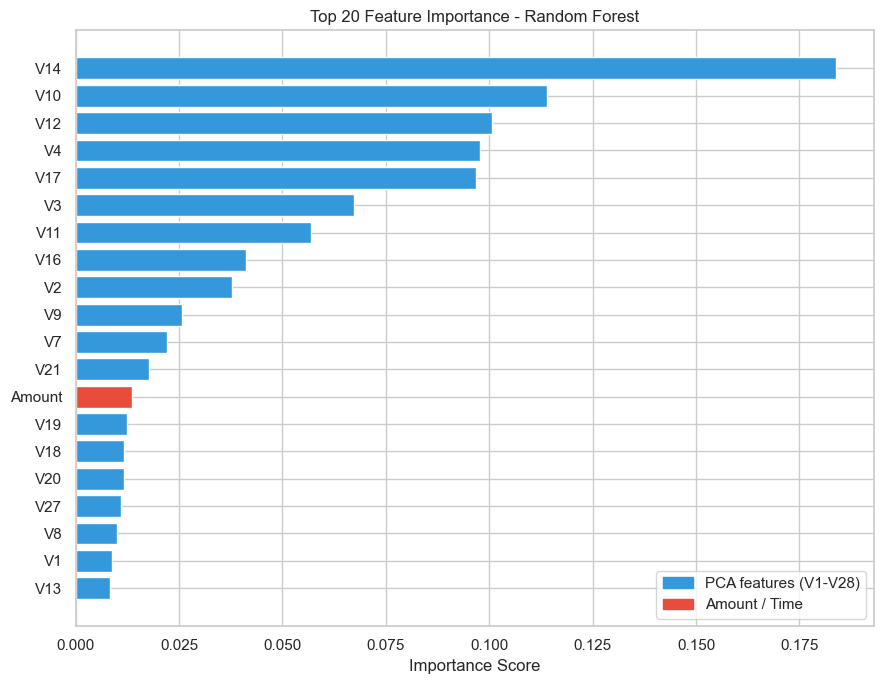

In [43]:
# Bieu do: feature importance cua Random Forest
feat_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_feat = feat_df.head(20)
colors   = ['#e74c3c' if f in ['Amount', 'Time'] else '#3498db' for f in top_feat['Feature']]

plt.figure(figsize=(9, 7))
plt.barh(top_feat['Feature'][::-1], top_feat['Importance'][::-1],
         color=colors[::-1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importance - Random Forest')
plt.legend(handles=[
    Patch(color='#3498db', label='PCA features (V1-V28)'),
    Patch(color='#e74c3c', label='Amount / Time')
])
plt.tight_layout()
save_fig(plt.gcf(), '16_random_forest_feature_importance')
plt.show()

In [44]:
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-score' : f1_score(y_test, y_pred),
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Score'])
metrics_df['Score'] = metrics_df['Score'].round(4)
print(metrics_df.to_string(index=False))

   Metric  Score
 Accuracy 0.9994
Precision 0.7961
   Recall 0.8367
 F1-score 0.8159


In [45]:
# Tim threshold tot nhat theo F1 cho Random Forest
thresholds = np.arange(0.1, 0.6, 0.01)
scores = [(t, f1_score(y_test, (y_pred_proba >= t).astype(int))) for t in thresholds]
best_t, best_f1 = max(scores, key=lambda x: x[1])

y_pred_tuned = (y_pred_proba >= best_t).astype(int)

print(f'Best threshold: {best_t:.2f}')
print()

metrics_tuned = {
    'Accuracy' : accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall'   : recall_score(y_test, y_pred_tuned),
    'F1-score' : f1_score(y_test, y_pred_tuned),
}
df_tuned = pd.DataFrame(metrics_tuned.items(), columns=['Metric', 'Score'])
df_tuned['Score'] = df_tuned['Score'].round(4)
print(df_tuned.to_string(index=False))

Best threshold: 0.48

   Metric  Score
 Accuracy 0.9994
Precision 0.7905
   Recall 0.8469
 F1-score 0.8177


In [ ]:
# Thu nghiem SMOTE de xu ly mat can bang
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_sm       = rf_smote.predict(X_test)
y_pred_proba_sm = rf_smote.predict_proba(X_test)[:, 1]

metrics_sm = {
    'Accuracy' : accuracy_score(y_test, y_pred_sm),
    'Precision': precision_score(y_test, y_pred_sm),
    'Recall'   : recall_score(y_test, y_pred_sm),
    'F1-score' : f1_score(y_test, y_pred_sm),
}
df_sm = pd.DataFrame(metrics_sm.items(), columns=['Metric', 'Score'])
df_sm['Score'] = df_sm['Score'].round(4)
print(df_sm.to_string(index=False))

In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb       = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

metrics_xgb = {
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'F1-score' : f1_score(y_test, y_pred_xgb),
}
df_xgb = pd.DataFrame(metrics_xgb.items(), columns=['Metric', 'Score'])
df_xgb['Score'] = df_xgb['Score'].round(4)
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba_xgb):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba_xgb):.4f}')
print()
print(df_xgb.to_string(index=False))

ROC-AUC : 0.9769
PR-AUC  : 0.8680

   Metric  Score
 Accuracy 0.9994
Precision 0.8058
   Recall 0.8469
 F1-score 0.8259


## Biểu đồ đánh giá mô hình

Các biểu đồ dưới đây nên chạy sau khi bạn đã train Random Forest, Random Forest + SMOTE và XGBoost. Chúng giúp so sánh mô hình và chọn threshold dựa trên Precision/Recall/F1 thay vì Accuracy.

Saved figure: figures\05_model_comparison.pdf


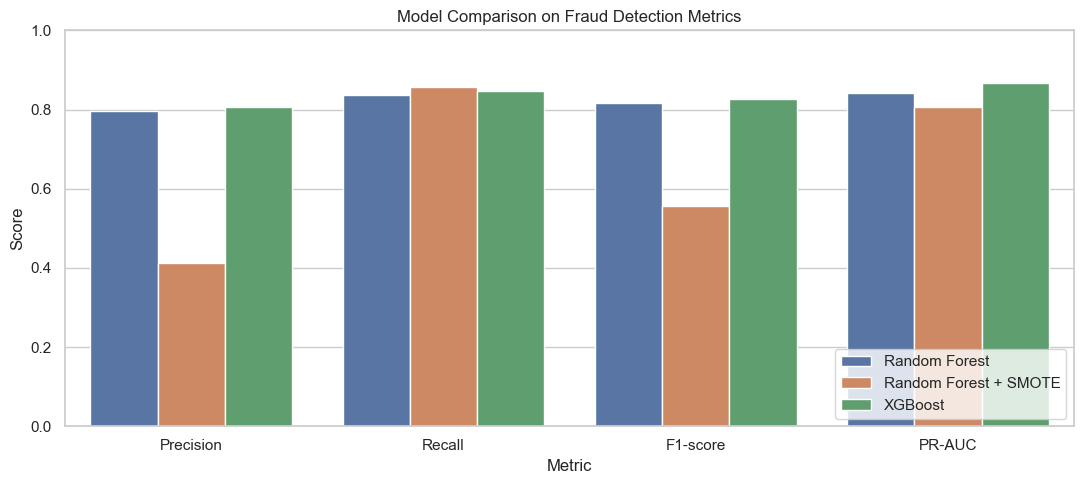

,Model,Accuracy,Precision,Recall,F1-score,PR-AUC,ROC-AUC
0,Random Forest,0.9994,0.7961,0.8367,0.8159,0.8425,0.9786
1,Random Forest + SMOTE,0.9976,0.4118,0.8571,0.5563,0.8053,0.9857
2,XGBoost,0.9994,0.8058,0.8469,0.8259,0.8680,0.9769


In [ ]:
# Bieu do: so sanh cac mo hinh
model_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1-score': f1_score(y_test, y_pred_lr),
        'PR-AUC': average_precision_score(y_test, y_pred_proba_lr),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr),
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'PR-AUC': average_precision_score(y_test, y_pred_proba),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
    },
    {
        'Model': 'Random Forest + SMOTE',
        'Accuracy': accuracy_score(y_test, y_pred_sm),
        'Precision': precision_score(y_test, y_pred_sm),
        'Recall': recall_score(y_test, y_pred_sm),
        'F1-score': f1_score(y_test, y_pred_sm),
        'PR-AUC': average_precision_score(y_test, y_pred_proba_sm),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_sm),
    },
    {
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-score': f1_score(y_test, y_pred_xgb),
        'PR-AUC': average_precision_score(y_test, y_pred_proba_xgb),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb),
    },
])

plot_df = model_results.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-score', 'PR-AUC'],
                             var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison on Fraud Detection Metrics')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '05_model_comparison')
plt.show()

model_results.round(4)


Saved figure: figures\06_roc_pr_comparison.pdf


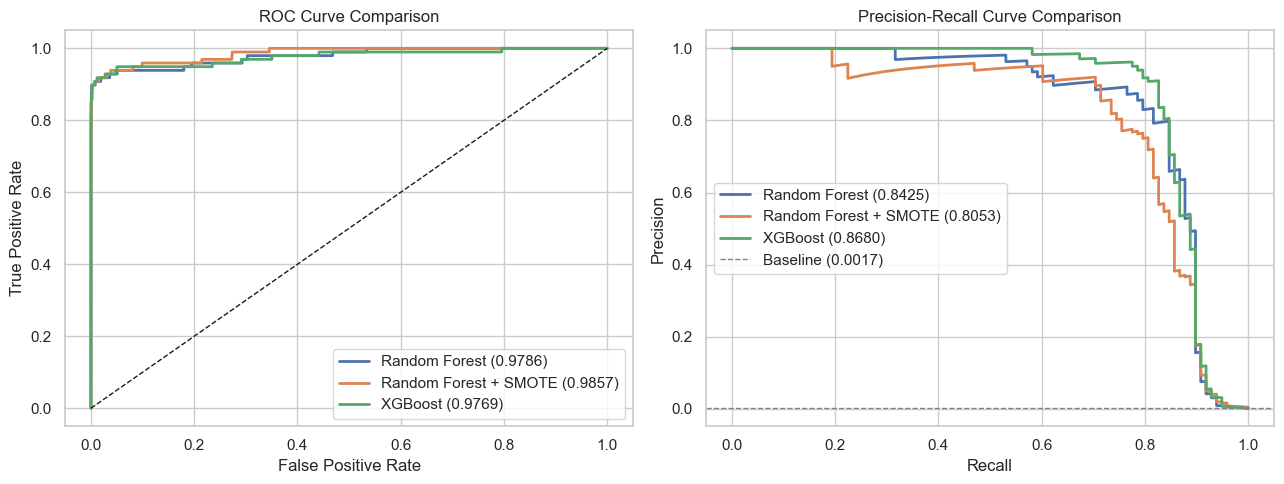

In [ ]:
# Bieu do: so sanh ROC va Precision-Recall giua cac mo hinh
models_for_curves = {
    'Logistic Regression': y_pred_proba_lr,
    'Random Forest': y_pred_proba,
    'Random Forest + SMOTE': y_pred_proba_sm,
    'XGBoost': y_pred_proba_xgb,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name, proba in models_for_curves.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{model_name} ({roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

for model_name, proba in models_for_curves.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, lw=2, label=f'{model_name} ({pr_auc:.4f})')

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline ({y_test.mean():.4f})')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '06_roc_pr_comparison')
plt.show()


Saved figure: figures\07_xgboost_threshold_tuning.pdf


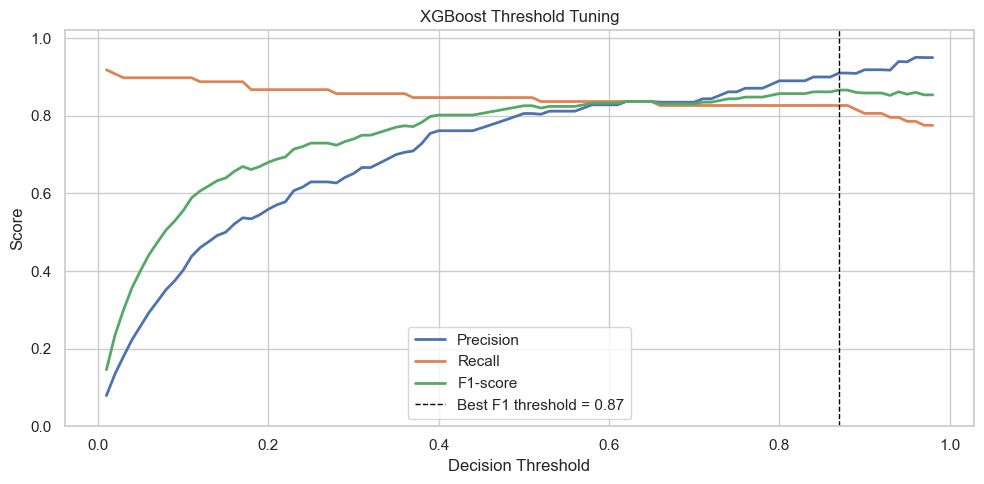

,Threshold,Precision,Recall,F1-score
86,0.87,0.9101,0.8265,0.8663


In [ ]:
# Bieu do: phan tich threshold cho XGBoost
thresholds = np.arange(0.01, 0.99, 0.01)
threshold_rows = []

for t in thresholds:
    pred_t = (y_pred_proba_xgb >= t).astype(int)
    threshold_rows.append({
        'Threshold': t,
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall': recall_score(y_test, pred_t, zero_division=0),
        'F1-score': f1_score(y_test, pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.loc[threshold_df['F1-score'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ['Precision', 'Recall', 'F1-score']:
    ax.plot(threshold_df['Threshold'], threshold_df[metric], lw=2, label=metric)

ax.axvline(best_row['Threshold'], color='black', linestyle='--', lw=1,
           label=f"Best F1 threshold = {best_row['Threshold']:.2f}")
ax.set_title('XGBoost Threshold Tuning')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
save_fig(fig, '07_xgboost_threshold_tuning')
plt.show()

best_row.to_frame().T.round(4)


## Stratified cross-validation

Một lần train/test split có thể bị ảnh hưởng bởi cách chia dữ liệu. Stratified cross-validation giúp đánh giá ổn định hơn, đặc biệt với dữ liệu fraud rất mất cân bằng.

In [ ]:
# Danh gia bang Stratified Cross-Validation tren tap train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

cv_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='aucpr', n_jobs=-1
    ),
}

cv_rows = []
for model_name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': model_name}
    for metric_name in scoring:
        values = scores[f'test_{metric_name}']
        row[f'{metric_name}_mean'] = values.mean()
        row[f'{metric_name}_std'] = values.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows)
cv_results.round(4)


In [ ]:
# Bieu do: ket qua cross-validation
cv_plot = cv_results[['Model', 'f1_mean', 'f1_std', 'pr_auc_mean', 'pr_auc_std']].copy()
cv_plot = cv_plot.rename(columns={'f1_mean': 'F1-score', 'pr_auc_mean': 'PR-AUC'})
plot_df = cv_plot.melt(id_vars='Model', value_vars=['F1-score', 'PR-AUC'],
                       var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Stratified Cross-Validation Results')
ax.set_ylabel('Mean Score Across 5 Folds')
ax.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, '09_cross_validation_results')
plt.show()


In [ ]:
# Bieu do: feature importance cua XGBoost
xgb_feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_,
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(xgb_feat_df['Feature'][::-1], xgb_feat_df['Importance'][::-1], color='#3498db')
ax.set_title('Top 20 Feature Importance - XGBoost')
ax.set_xlabel('Importance Score')
plt.tight_layout()
save_fig(fig, '10_xgboost_feature_importance')
plt.show()

xgb_feat_df.reset_index(drop=True)


In [ ]:
# Bieu do: confusion matrix cua XGBoost sau khi tune threshold
y_pred_xgb_tuned = (y_pred_proba_xgb >= best_row['Threshold']).astype(int)
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
cm_xgb_pct = cm_xgb_tuned.astype(float) / cm_xgb_tuned.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_xgb_tuned, display_labels=['Normal', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'XGBoost Confusion Matrix\nThreshold = {best_row["Threshold"]:.2f}')

sns.heatmap(cm_xgb_pct, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: Normal', 'Pred: Fraud'],
            yticklabels=['True: Normal', 'True: Fraud'])
axes[1].set_title('XGBoost Confusion Matrix (%)')

plt.tight_layout()
save_fig(fig, '11_xgboost_tuned_confusion_matrix')
plt.show()

print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Normal', 'Fraud']))


## Kết luận gợi ý cho báo cáo

- Dữ liệu mất cân bằng rất nặng, fraud chỉ chiếm khoảng 0.17%, nên Accuracy không phải metric chính.
- Precision, Recall, F1-score và PR-AUC phù hợp hơn để đánh giá khả năng phát hiện fraud.
- Logistic Regression là baseline tuyến tính để so sánh.
- Random Forest xử lý mất cân bằng bằng `class_weight='balanced'` và cho kết quả tốt hơn baseline đơn giản.
- SMOTE tăng Recall nhưng có thể làm Precision giảm mạnh, nghĩa là mô hình báo động giả nhiều hơn.
- XGBoost với `scale_pos_weight` thường là mô hình mạnh nhất trong notebook này theo PR-AUC/F1.
- Threshold tuning cho XGBoost cho phép điều chỉnh trade-off: giảm false negative nếu ưu tiên bắt fraud, hoặc giảm false positive nếu ưu tiên ít báo động giả.